# Pyspark envrioment Set-up

In [30]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()

# Importing Open Food Facts Dataset

## our dataset is a crowded sourced dataset of food from around the world.

In [31]:
food_data = spark.read.options(delimiter="\t",header=True).csv(r"C:\Users\sanid\Downloads\en.openfoodfacts.org.products.csv")

In [32]:
food_data.count()

3371999

In [33]:
food_data.show(n = 10)

+--------------------+--------------------+--------------+----------+--------------------+---------------+----------------------+----------------+--------------+---------------------+--------------------+------------------------+------------+--------+---------+--------------+------------+--------------+-------+-----------+--------------------+--------------------+--------------------+-------+------------+----------+--------------------+-------------------------+-----------+------------+---------+---------+--------------+------------------------+------+-----------+---------------+------+---------+----------------+-------------+--------------------+--------------------+-------------------------+---------+------------+------+-----------+---------+------------+----------------+-----------------+-----------+---------+--------------+------------+----------------+----------------+----------+--------------------+--------------+-----------------+--------------------+--------------------+-------

## Schema

Taking a look at the dataset's schema we see there are multiple types of columns including nutrition facts and other identifying columns that aren't relevant to our analysis

In [34]:
food_data.printSchema()

root
 |-- code: string (nullable = true)
 |-- url: string (nullable = true)
 |-- creator: string (nullable = true)
 |-- created_t: string (nullable = true)
 |-- created_datetime: string (nullable = true)
 |-- last_modified_t: string (nullable = true)
 |-- last_modified_datetime: string (nullable = true)
 |-- last_modified_by: string (nullable = true)
 |-- last_updated_t: string (nullable = true)
 |-- last_updated_datetime: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- abbreviated_product_name: string (nullable = true)
 |-- generic_name: string (nullable = true)
 |-- quantity: string (nullable = true)
 |-- packaging: string (nullable = true)
 |-- packaging_tags: string (nullable = true)
 |-- packaging_en: string (nullable = true)
 |-- packaging_text: string (nullable = true)
 |-- brands: string (nullable = true)
 |-- brands_tags: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- categories_tags: string (nullable = true)
 |-- categories_e

# Exploratory Analysis

The first thing we wanted to look at was which countries are the most represented in this dataset. So we created a new spark dataframe where we grouped food by "countrie_tags", which is the country of each foods' origin as well as the count for each country.

In [35]:
from pyspark.sql.functions import col
countries = food_data.groupBy("countries_tags").count().persist()

Next we filtered the countries dataframe by the count column where we only looked at countries with at least 5,000 foods in the dataset and sorted by descending to look at the countries with the most foods in the dataset. France is the most represented country with over 800,000 french foods in the dataset

In [36]:
countries = countries.filter(col("count") > 5000).orderBy("count",ascending = False)
countries.show()

+--------------------+------+
|      countries_tags| count|
+--------------------+------+
|           en:france|980217|
|    en:united-states|610031|
|            en:spain|302964|
|            en:italy|225095|
|          en:germany|223049|
|   en:united-kingdom|115031|
|           en:canada| 83303|
|      en:switzerland| 70980|
|          en:belgium| 68596|
|          en:ireland| 55245|
|        en:australia| 41581|
|            en:world| 32591|
|                NULL| 24676|
|en:united-states,...| 23659|
|      en:netherlands| 21118|
|           en:brazil| 17272|
|en:france,en:germany| 17115|
|           en:poland| 15903|
|           en:russia| 15812|
|          en:romania| 13303|
+--------------------+------+
only showing top 20 rows



## Country Representation

In order to visualize the countries dataframe, I converted it into a pandas dataframe to create a bar chart. Once again, France is the country with the highest foods originating from it.

### Bar Chart

Bar chart of country distribution.

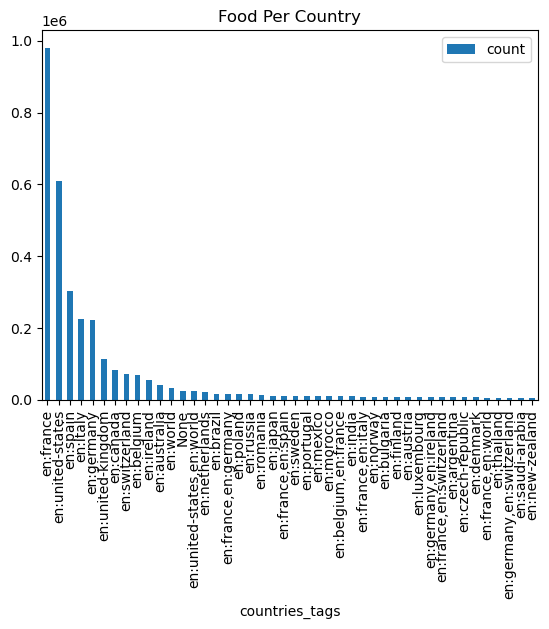

In [37]:
countries_df = countries.toPandas()
countries_df.plot.bar(x = "countries_tags", y = "count", title = "Food Per Country");

### Pie Chart

Pie chart of country distribution.

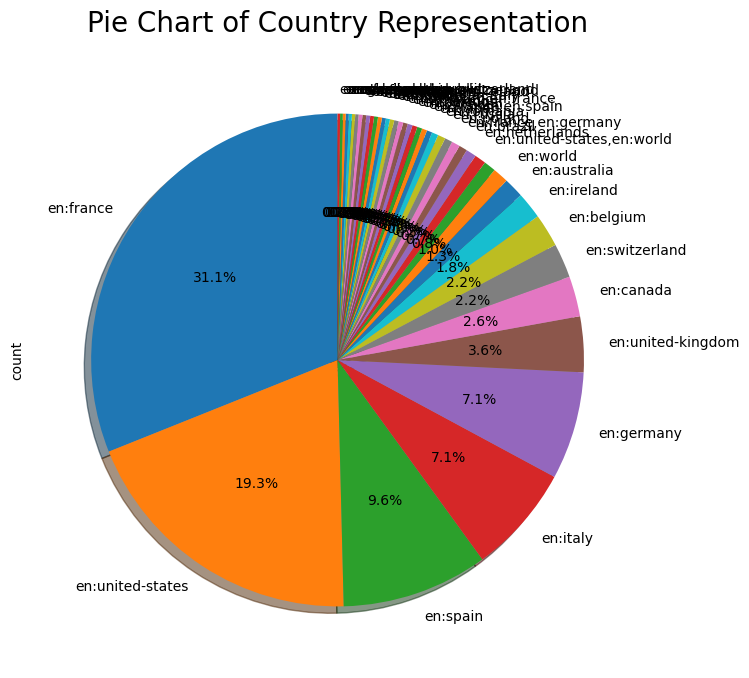

In [38]:
import matplotlib.pyplot as plt

countries_df['count'].plot(kind = 'pie', subplots = True, shadow = True, startangle = 90, figsize=(8,8), autopct='%1.1f%%', labels = countries_df['countries_tags'])
plt.title("Pie Chart of Country Representation", y = 1.02, fontsize = 20)
plt.show()

We also created more visualizations using tableau from our final data set that we create in the next section.

# Data Processing

The first thing we want to do is filter our dataset for foods of French origin only. French food represents a majority of the food in our dataset. There is also a column called "nutriscore_grade" which is the grade given by the French national food grading system called nutriscore. It grades food as healthy or unhealthy on a scale from A to E.

## Dataset filtered for foods from France

In [39]:
import pyspark.sql.functions as F

french_food = food_data.filter(F.col("countries_tags") == 'en:france')
french_food.show()

+--------------------+--------------------+--------------+----------+--------------------+---------------+----------------------+----------------+--------------+---------------------+--------------------+------------------------+------------+--------+---------+--------------+------------+--------------+-------------+-------------+--------------------+--------------------+--------------------+-------+------------+----------+--------------------+-------------------------+-------------+----------------+----------------+---------+--------------+------------------------+------+-----------+---------------+-------------+---------+--------------+------------+--------------------+--------------------+-------------------------+----------+------------+------+-----------+---------+------------+----------------+-----------------+-----------+---------+--------------+------------+----------------+----------------+----------+--------------------+--------------------+--------------------+--------------

The following is the shape of our data set. As we can see there are 800,451 which matches the number we saw earlier when grouping by country and adding a count column.

In [40]:
print(french_food.count(), len(french_food.columns))

980217 206


## Dataset of french foods keeping only columns with nutritional values

Next we only decided to keep nutritional values. We want to use nutritional values to predict the health grade of a given food. Specifically, the columns we are keeping are 'code', 'additives_n', 'energy_100g', 'fat_100g', 'fiber_100g', 'proteins_100g', 'sugars_100g', 'sodium_100g', 'salt_100g', 'carbohydrates_100g', 'nutriscore_grade'.

In [41]:
french_food = french_food[['code', 'additives_n', 'energy_100g', 'fat_100g', 'fiber_100g', 'proteins_100g', 'sugars_100g', 'sodium_100g', 'salt_100g', 'carbohydrates_100g', 'nutriscore_grade']]
french_food.show()

+--------------------+-----------+-----------+--------+----------+-------------+-----------+-----------+---------+------------------+----------------+
|                code|additives_n|energy_100g|fat_100g|fiber_100g|proteins_100g|sugars_100g|sodium_100g|salt_100g|carbohydrates_100g|nutriscore_grade|
+--------------------+-----------+-----------+--------+----------+-------------+-----------+-----------+---------+------------------+----------------+
|   00000000000000225|       NULL|       NULL|    NULL|      NULL|         NULL|       NULL|       NULL|     NULL|              NULL|         unknown|
|00000000000026772226|       NULL|        238|     0.2|      NULL|           10|        3.9|      0.036|     0.09|               3.9|               a|
|       0000000000017|       NULL|       1569|       7|      NULL|          7.8|         15|       0.56|      1.4|              70.1|         unknown|
|       0000000000031|       NULL|       NULL|    NULL|      NULL|         NULL|       NULL|  

So far we have the original 800,451 rows, but now we have 11 columns

In [42]:
print(french_food.count(), len(french_food.columns))

980217 11


## Dropping null values

However, in the previous spark dataframe, we see that there are many missing values. Any foods with missing mutritional facts won't help us in our analysis. So, we're going to drop them.

In [43]:
french_food = french_food.na.drop()
french_food.show()

+-------------+-----------+-----------+--------+----------+-------------+-----------+-----------+---------+------------------+----------------+
|         code|additives_n|energy_100g|fat_100g|fiber_100g|proteins_100g|sugars_100g|sodium_100g|salt_100g|carbohydrates_100g|nutriscore_grade|
+-------------+-----------+-----------+--------+----------+-------------+-----------+-----------+---------+------------------+----------------+
|0000000000100|          0|        936|     8.2|         0|          5.1|         22|       1.84|      4.6|                29|               d|
|0000000001199|          5|        916|     5.9|       2.8|          9.7|        1.7|     0.1856|    0.464|              30.3|         unknown|
|0000000002264|          0|        866|     6.7|       1.7|          8.9|        0.6|       0.16|      0.4|              27.5|         unknown|
|0000000003827|          2|        720|     4.4|       2.7|          8.4|        4.6|      1.432|     3.58|              23.3|         u

After dropping null values, we end up with out final dataset with 78,451 rows and 11 columns

In [44]:
print(french_food.count(), len(french_food.columns))

126639 11


## French data schemea

Need to change data types. Nutritional values need to be floats

In [45]:
french_food.printSchema()

root
 |-- code: string (nullable = true)
 |-- additives_n: string (nullable = true)
 |-- energy_100g: string (nullable = true)
 |-- fat_100g: string (nullable = true)
 |-- fiber_100g: string (nullable = true)
 |-- proteins_100g: string (nullable = true)
 |-- sugars_100g: string (nullable = true)
 |-- sodium_100g: string (nullable = true)
 |-- salt_100g: string (nullable = true)
 |-- carbohydrates_100g: string (nullable = true)
 |-- nutriscore_grade: string (nullable = true)



## Changing attributes' data types

In [46]:
from pyspark.sql.types import FloatType, IntegerType

french_food = french_food \
  .withColumn("additives_n", french_food["additives_n"].cast(FloatType()))  \
  .withColumn("energy_100g", french_food["energy_100g"].cast(FloatType()))  \
  .withColumn("fat_100g", french_food["fat_100g"].cast(FloatType()))  \
  .withColumn("fiber_100g", french_food["fiber_100g"].cast(FloatType()))  \
  .withColumn("proteins_100g", french_food["proteins_100g"].cast(FloatType()))  \
  .withColumn("sugars_100g", french_food["sugars_100g"].cast(FloatType()))  \
  .withColumn("sodium_100g", french_food["sodium_100g"].cast(FloatType()))  \
  .withColumn("salt_100g", french_food["salt_100g"].cast(FloatType()))  \
  .withColumn("carbohydrates_100g", french_food["carbohydrates_100g"].cast(FloatType()))  \

french_food.printSchema()

root
 |-- code: string (nullable = true)
 |-- additives_n: float (nullable = true)
 |-- energy_100g: float (nullable = true)
 |-- fat_100g: float (nullable = true)
 |-- fiber_100g: float (nullable = true)
 |-- proteins_100g: float (nullable = true)
 |-- sugars_100g: float (nullable = true)
 |-- sodium_100g: float (nullable = true)
 |-- salt_100g: float (nullable = true)
 |-- carbohydrates_100g: float (nullable = true)
 |-- nutriscore_grade: string (nullable = true)



# Nutriscore Grade Distribtuion

##  Creating a new dataframe grouping by nutriscore_grade and each grades' count

Now, we want to look at the nutriscore_grade distribution for the remaining French food in our dataset. We see that food graded as D is the most common grade in our dataset followed closely by A and C.

In [47]:
grades = french_food.groupBy("nutriscore_grade").count().orderBy("count", ascending = False).persist()
grades.show()

+----------------+-----+
|nutriscore_grade|count|
+----------------+-----+
|               a|25160|
|               d|24620|
|               c|23351|
|         unknown|19636|
|               b|16877|
|               e|14085|
|  not-applicable| 2910|
+----------------+-----+



Once again we converted our grades spark dataframe into a pandas dataframe in order to create visualizations

## Visualizing Nutriscore Grade

### Bar Chart of Nutriscore Grade Distribution

Grades D, A, and C most represented.

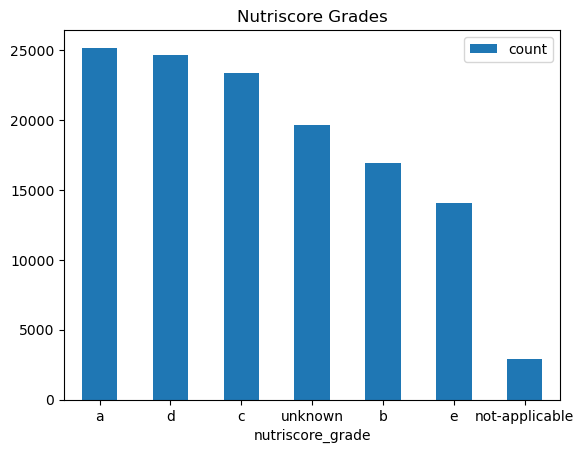

In [48]:
import matplotlib.pyplot as plt

grades_df = grades.toPandas()
grades_df.plot.bar(x = "nutriscore_grade", y = "count", rot = 0, title = "Nutriscore Grades");

### Pie Chart of Nutriscore Grade Distribution

Grades D, A, and C are pretty evenly distributed.

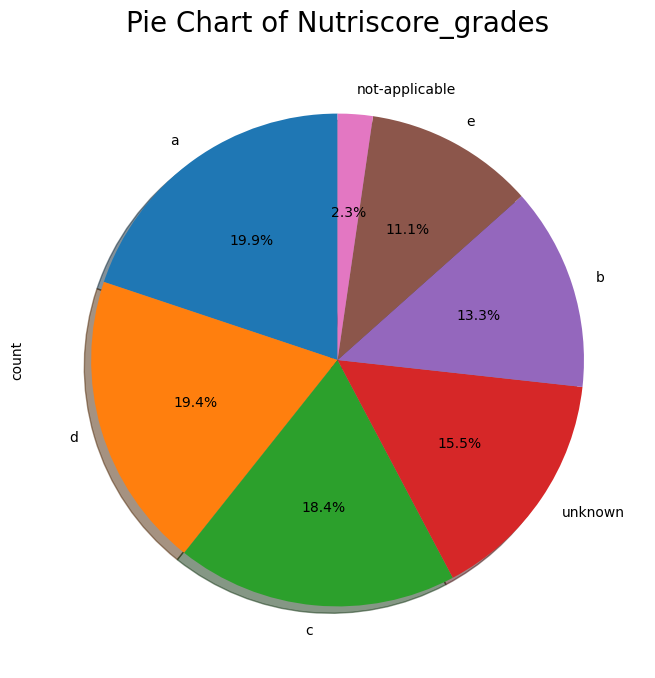

In [49]:
import matplotlib.pyplot as plt

grades_df['count'].plot(kind = 'pie', subplots = True, shadow = True, startangle = 90, figsize=(8,8), autopct='%1.1f%%', labels = grades_df['nutriscore_grade'])
plt.title("Pie Chart of Nutriscore_grades", y = 1.02, fontsize = 20)
plt.show()

# Converting our final french food dataset into a pandas dataframe and exporting it to csv file to be used in tableau for further visualizations

In [50]:
french_food_df = french_food.toPandas()
french_food_df.to_csv('/content/drive/MyDrive/IDS 561/Project/cleaned_fooddata_nutriscore_grades.csv', encoding = 'utf-8', index = False, header = True)

OSError: Cannot save file into a non-existent directory: '\content\drive\MyDrive\IDS 561\Project'

# Healthy and Unhealthy Food

Our goal will be to build a classifer that can predict whether a given food will be healthy or unhealthy based on its nutritional value. Healthy Food will be considered as foods with a nutriscore grade of A or B. Unhealthy food will be foods with nutriscore grades of C or worse. We will be left with a binary column named healthy replacing the old nutriscore_grade column.

In [52]:
from pyspark.sql.functions import regexp_replace

food_health = french_food \
  .withColumn("nutriscore_grade", regexp_replace('nutriscore_grade', "a", "1")) \
  .withColumn("nutriscore_grade", regexp_replace('nutriscore_grade', "b", "1")) \
  .withColumn("nutriscore_grade", regexp_replace('nutriscore_grade', "c", "0")) \
  .withColumn("nutriscore_grade", regexp_replace('nutriscore_grade', "d", "0")) \
  .withColumn("nutriscore_grade", regexp_replace('nutriscore_grade', "e", "0")) \

food_health = food_health.withColumnRenamed("nutriscore_grade", "healthy")

food_health = food_health.withColumn("healthy", food_health["healthy"].cast(IntegerType()))

food_health.show()

+-------------+-----------+-----------+--------+----------+-------------+-----------+-----------+---------+------------------+-------+
|         code|additives_n|energy_100g|fat_100g|fiber_100g|proteins_100g|sugars_100g|sodium_100g|salt_100g|carbohydrates_100g|healthy|
+-------------+-----------+-----------+--------+----------+-------------+-----------+-----------+---------+------------------+-------+
|0000000000100|        0.0|      936.0|     8.2|       0.0|          5.1|       22.0|       1.84|      4.6|              29.0|      0|
|0000000001199|        5.0|      916.0|     5.9|       2.8|          9.7|        1.7|     0.1856|    0.464|              30.3|   NULL|
|0000000002264|        0.0|      866.0|     6.7|       1.7|          8.9|        0.6|       0.16|      0.4|              27.5|   NULL|
|0000000003827|        2.0|      720.0|     4.4|       2.7|          8.4|        4.6|      1.432|     3.58|              23.3|   NULL|
|0000000004510|        1.0|      477.0|     8.1|       

## Visualizing Healthy and Unhealthy Food

### Creating a new dataframe grouping by 1 or 0 and each one's count

In [53]:
healthy = food_health.groupBy("healthy").count().orderBy("count", ascending = False).persist()
healthy.show()

+-------+-----+
|healthy|count|
+-------+-----+
|      0|62056|
|      1|42037|
|   NULL|22546|
+-------+-----+



### Bar Chart comparing Healhy and Unhealthy food

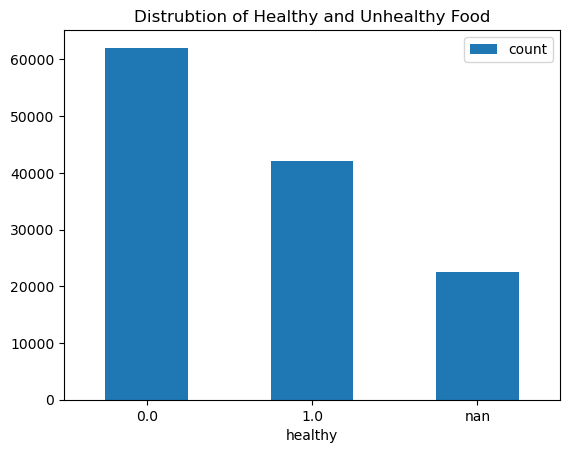

In [54]:
import matplotlib.pyplot as plt

healthy_df = healthy.toPandas()
healthy_df.plot.bar(x = "healthy", y = "count", rot = 0, title = "Distrubtion of Healthy and Unhealthy Food");

### Pie Chart of Healthy and Unhealthy Food

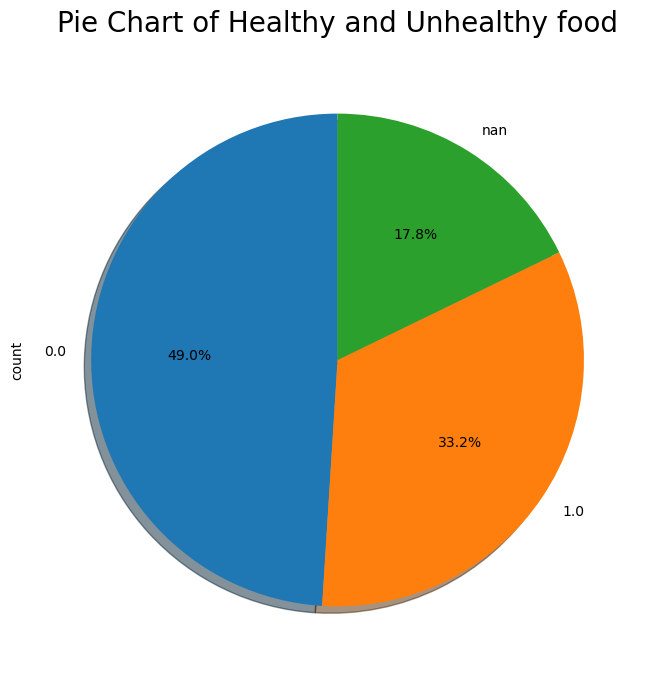

In [55]:
import matplotlib.pyplot as plt

healthy_df['count'].plot(kind = 'pie', subplots = True, shadow = True, startangle = 90, figsize=(8,8), autopct='%1.1f%%', labels = healthy_df['healthy'])
plt.title("Pie Chart of Healthy and Unhealthy food", y = 1.02, fontsize = 20)
plt.show()

As we can see the majority of the dataset is made up of unhealthy foods.

# Modeling using the regular Pandas Libraries and Sklearn


Since our final dataset is small enough to use pandas we will create a model to compare our results with the pyspark library. Converting the spark dataframe to pandas dataframe and exporting to a CSV file

In [56]:
healthy_food_df = food_health.toPandas()
healthy_food_df.to_csv('healthy_food.csv', encoding = 'utf-8', index = False, header = True)

In [57]:
healthy_food_df.drop('code', axis=1, inplace=True)
healthy_food_df

,additives_n,energy_100g,fat_100g,fiber_100g,proteins_100g,sugars_100g,sodium_100g,salt_100g,carbohydrates_100g,healthy
0,0.0,936.0,8.2,0.0,5.1,22.0,1.8400,4.600,29.000000,0.0
1,5.0,916.0,5.9,2.8,9.7,1.7,0.1856,0.464,30.299999,NaN
2,0.0,866.0,6.7,1.7,8.9,0.6,0.1600,0.400,27.500000,NaN
3,2.0,720.0,4.4,2.7,8.4,4.6,1.4320,3.580,23.299999,NaN
4,1.0,477.0,8.1,1.7,3.9,1.4,0.1240,0.310,5.700000,NaN
...,...,...,...,...,...,...,...,...,...,...
126634,2.0,753.0,12.0,2.3,16.0,0.7,0.4000,1.000,0.800000,1.0
126635,1.0,2648.0,49.0,5.1,10.0,33.0,0.0560,0.140,36.000000,0.0
126636,0.0,1519.0,7.9,11.6,12.6,5.5,0.0000,0.000,65.500000,NaN
126637,0.0,0.0,5.0,25.0,32.0,0.5,0.0800,0.200,2.000000,1.0
